# Import library

In [1]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import wandb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from utilis import Utility, Data, Visualization, Score, save_config_and_lr, load_config_and_lr
from chunk_handle import get_chunk_indices, iter_chunks, compute_global_image_stats, compute_global_label_stats, save_transform_and_scaler, load_transform_and_scaler

/Users/viethuy/Working_space/Neurips/Neurips2025_Weak_lensing/utilis.py:408: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  DEVICE = "mps" if torch.has_mps else "cpu"


In [3]:
# chunk_dir= "./dataset/chunk_kappa_noise_new"
# indices=np.arange(10)
# means, stds=compute_global_image_stats(chunk_dir, indices)
# label_scaler=compute_global_label_stats(chunk_dir, indices)

In [2]:
# from torchvision import transforms
# transform = transforms.Compose([
#     transforms.ToTensor(),     
#     transforms.Normalize(mean=[means], std=[stds]),   
# ])
# print(f"Image stats (from train set): Mean={means}, Std={stds}")
# print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

# save_transform_and_scaler(means, stds, label_scaler, transform_file='./side_module/transform_params.pkl', scaler_file='./side_module/label_scaler.pkl')

# If the transform and scaler is avaiable, ignore that

In [3]:
transform, label_scaler = load_transform_and_scaler(transform_file='./side_module/transform_params.pkl', scaler_file='./side_module/label_scaler.pkl')


Loaded transform with Mean=-0.00016638042870908976, Std=0.02047532983124256
Loaded label scaler with Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


In [4]:
l_edge = np.logspace(2, 4, 11)
Nbins = len(l_edge)-1

In [5]:
def power_spectrum(x, pixsize, kedge):
    """
    Compute the azimuthally averaged 2D power spectrum of a real-valued 2D field.

    Parameters:
    -----------
    x : 2D numpy array
        Input real-space map (e.g., an image or simulated field).
        Must be a 2D array with shape (N_y, N_x).
    
    pixsize : float
        Physical size of each pixel in the map (e.g., arcmin, Mpc, etc.).
        Units should be consistent with the units used for `kedge`.
    
    kedge : 1D array-like
        Bin edges in wavenumber space (k), used to bin the power spectrum.
        Should be monotonically increasing and cover the k-range of interest.

    Returns:
    --------
    power_k : 1D numpy array
        The average wavenumber in each k bin (excluding the DC bin).
    
    power : 1D numpy array
        The binned, azimuthally averaged power spectrum corresponding to `power_k`.
        Normalized per unit area.
    """

    # Ensure the input array is 2D
    assert x.ndim == 2

    # Compute the 2D FFT of the input map and take its squared magnitude (power spectrum)
    xk = np.fft.rfft2(x)  # Real-to-complex FFT (along last axis)
    xk2 = (xk * xk.conj()).real  # Power spectrum: |FFT|^2

    # Get the shape of the input map
    Nmesh = x.shape

    # Compute the wavenumber grid (k-space)
    k = np.zeros((Nmesh[0], Nmesh[1]//2+1))
    # Square of the frequency in the first axis
    k += np.fft.fftfreq(Nmesh[0], d=pixsize).reshape(-1, 1) ** 2
    # Square of the frequency in the second axis (real FFT)
    k += np.fft.rfftfreq(Nmesh[1], d=pixsize).reshape(1, -1) ** 2
    # Convert from (1/length)^2 to angular frequency in radian units
    k = k ** 0.5 * 2 * np.pi

    # Bin each k value according to the bin edges provided in kedge
    index = np.searchsorted(kedge, k)

    # Bin the power values, number of modes, and wavenumbers
    power = np.bincount(index.flatten(), weights=xk2.flatten())
    Nmode = np.bincount(index.flatten())
    power_k = np.bincount(index.flatten(), weights=k.flatten())

    # Adjust for symmetry in the real FFT: include the mirrored part (excluding Nyquist frequency)
    if Nmesh[1] % 2 == 0:  # Even number of columns
        power += np.bincount(index[...,1:-1].flatten(), weights=xk2[...,1:-1].flatten())
        Nmode += np.bincount(index[...,1:-1].flatten())
        power_k += np.bincount(index[...,1:-1].flatten(), weights=k[...,1:-1].flatten())
    else:  # Odd number of columns
        power += np.bincount(index[...,1:].flatten(), weights=xk2[...,1:].flatten())
        Nmode += np.bincount(index[...,1:].flatten())
        power_k += np.bincount(index[...,1:].flatten(), weights=k[...,1:].flatten())

    # Exclude the first bin (typically corresponds to DC mode)
    power = power[1:len(kedge)]
    Nmode = Nmode[1:len(kedge)]
    power_k = power_k[1:len(kedge)]

    # Average the power and wavenumber in each bin, only where Nmode > 0
    select = Nmode > 0
    power[select] = power[select] / Nmode[select]
    power_k[select] = power_k[select] / Nmode[select]

    # Normalize the power spectrum by the map area
    power *= pixsize ** 2 / Nmesh[0] / Nmesh[1]

    # Return the binned k values and corresponding power spectrum
    return power_k, power

In [6]:
num_chunks=25
indices=np.arange(num_chunks)

In [7]:
pixelsize_arcmin = 2 # pixel size in arcmin
pixelsize_radian = pixelsize_arcmin / 60 / 180 * np.pi

In [8]:
# for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
#             # Load single chunk (assumes it fits in memory)
#             noisy_chunk, label_chunk, _ = next(iter_chunks("./dataset/chunk_kappa_noise_new", indices=[chunk_idx]))
#             Ncosmo, Nsys = noisy_chunk.shape[0], noisy_chunk.shape[1]
#             Cl =  np.zeros((Ncosmo, Nsys, Nbins))

#             for i in range(Ncosmo):
#                 for j in range(Nsys):
#                     l, Cl[i,j] = power_spectrum(noisy_chunk[i,j].astype(np.float32
#                 ), pixelsize_radian, l_edge)

#             Utility.save_np(data_dir="./dataset/power_scpectrum", file_name=f"Spec_chunk_{chunk_idx}.npy",data=Cl)

In [10]:
# for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
#     noisy_chunk, label_chunk, _ = next(iter_chunks("./dataset/chunk_kappa_noise_new", indices=[chunk_idx]))
#     Ncosmo, Nsys = noisy_chunk.shape[0], noisy_chunk.shape[1]
#     logCl = np.log10(Utility.load_np(data_dir="./dataset/power_scpectrum", file_name=f"Spec_chunk_{chunk_idx}.npy"))
#     mean_logCl = np.mean(logCl, 1)
#     Utility.save_np(data_dir="./dataset/meanlogPS", file_name=f"Spec_chunk_{chunk_idx}.npy",data=mean_logCl)
#     delta = (logCl - mean_logCl[:,None])
#     cov_logCl = [(delta[i].T @ delta[i] / (len(delta[i])-delta.shape[-1]-2))[None] for i in range(Ncosmo)]
#     cov_logCl = np.concatenate(cov_logCl, 0)
#     Utility.save_np(data_dir="./dataset/CovlogPS", file_name=f"Spec_chunk_{chunk_idx}.npy", data=cov_logCl)
#     print(f"shape of cov_logCl: {cov_logCl.shape}, shape of mean_logCl: {mean_logCl.shape}")

Chunks:   4%|▍         | 1/25 [00:01<00:35,  1.46s/it]

shape of cov_logCl: (101, 10, 10), shape of mean_logCl: (101, 10)


Chunks:   8%|▊         | 2/25 [00:02<00:23,  1.01s/it]

shape of cov_logCl: (101, 10, 10), shape of mean_logCl: (101, 10)


Chunks:  12%|█▏        | 3/25 [00:02<00:18,  1.18it/s]

...

Chunks:  92%|█████████▏| 23/25 [00:14<00:01,  1.75it/s]

shape of cov_logCl: (101, 10, 10), shape of mean_logCl: (101, 10)


Chunks:  96%|█████████▌| 24/25 [00:15<00:00,  1.77it/s]

shape of cov_logCl: (101, 10, 10), shape of mean_logCl: (101, 10)


shape of cov_logCl: (101, 10, 10), shape of mean_logCl: (101, 10)


# Model architecture

In [ ]:
from Models import Spectrum_CNN

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from vit_pytorch import ViT
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


In [ ]:

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, total=len(train_loader), desc="Training")
    for (images, specs), targets in train_loader:
        images = images.to(device, dtype=torch.float32)
        specs = specs.to(device, dtype=torch.float32)
        targets = targets.to(device, dtype=torch.float32)
        optimizer.zero_grad()
        outputs = model((images, specs))
        # print(f"input shape: {inputs.shape}, target shape: {targets.shape}")
        # print(f"num of cosmo:{len(targets[:,0].unique())}")
        # print(f"num of cosmo_2:{len(targets[:,1].unique())}")

        # plt.hist(targets[:,0].cpu().numpy().flatten(), bins=500, alpha=0.5) # Giải nén tuple từ DataLoader
        # file_name = "histogram.png"  # Bạn có thể thay đổi tên file
        # save_path = os.path.join("./plt", file_name)
        # plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Lưu với độ phân giải 300 DPI, căn chỉnh gọn gàng
        # # Đóng biểu đồ để tránh hiển thị trên màn hình (nếu không cần)
        # plt.close() 


        # inputs, targets = inputs.to(device), targets.to(device)
        
        # optimizer.zero_grad()
        # outputs = model(inputs)
        # print(outputs)
        # print("Outputs shape:", outputs.shape)  # In ra kích thước của outputs để kiểm tra
        # print("Targets shape:", targets.shape)  # In ra kích thước của targets để kiểm tra
        loss = criterion(outputs, targets)  # Gọi hàm mất mát
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating")
    with torch.no_grad():
        for (images, specs), targets in dataloader:
            images = images.to(device, dtype=torch.float32)
            specs = specs.to(device, dtype=torch.float32)
            targets = targets.to(device, dtype=torch.float32)
            outputs = model((images, specs))
            total_loss += loss_fn(outputs, targets).item()
            
    return total_loss / len(dataloader)


In [16]:
class CosmologyDataset(Dataset):
    def __init__(self, data, specs, labels=None, transform=None):
        self.data = data  # (N, H, W)
        self.specs = specs  # (N, 10)
        self.labels = labels  # (N, num_targets)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item_data = self.data[idx]
        if self.transform:
            item_data = self.transform(item_data)
        if len(item_data.shape) == 2:
            item_data = item_data.unsqueeze(0)  # (1, H, W)
        item_spec = torch.tensor(self.specs[idx], dtype=torch.float32)
        if self.labels is not None:
            item_label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return (item_data, item_spec), item_label
        else:
            return (item_data, item_spec)

In [17]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, specs, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.specs = specs
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item_data = self.data[idx]
        if self.transform:
            item_data = self.transform(item_data)
        if len(item_data.shape) == 2:
            item_data = item_data.unsqueeze(0)  # (1, H, W)
        item_spec = torch.tensor(self.specs[idx], dtype=torch.float32)
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return (item_data, item_spec), label
        else:
            return (item_data, item_spec)

    # def __getitem__(self, idx):
    #     image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
    #     if self.transform:
    #         image = self.transform(image) 
    #     if self.labels is not None:
    #         label = self.labels[idx].astype(np.float32)
    #         label = torch.from_numpy(label)
    #         if self.label_transform:
    #             label = self.label_transform(label)
    #         return image, label
    #     else:
    #         return image

In [ ]:
import wandb
import os
import numpy as np
from typing import Optional, Tuple, Generator, Dict, Any
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import time
from tqdm import tqdm
import pickle
import wandb  # Import Weights & Biases
def incremental_train(model: nn.Module, 
                      config,
                      optimizer: optim.Optimizer, 
                      criterion: nn.Module, 
                      chunk_dir: str,
                      split_ratio: float = 0.8,
                      epochs_per_chunk: int = 1,
                      device: str = 'mps' if torch.backends.mps.is_available() else 'cpu',
                      verbose: bool = False,
                      log_file: str = None,
                      config_file: str = None) -> Dict[str, Any]:
    """
    Incrementally train a PyTorch model across chunks without loading the entire dataset.
    
    - Loads one chunk at a time.
    - Splits each chunk into train/test sets.
    - Trains the model on the train set using batches (for memory efficiency within chunk).
    - Validates once per epoch using concatenated validation data from all chunks.
    - Logs training progress to a text file and Weights & Biases (including learning rate).
    - Uses tqdm for progress visualization.
    - Saves config and final learning rate in a single timestamped folder.
    - Returns a summary dict with loss history, etc.
    
    Args:
        model: PyTorch model (nn.Module).
        optimizer: PyTorch optimizer.
        criterion: Loss function (e.g., nn.MSELoss()).
        chunk_dir: Directory containing chunk files.
        split_ratio: Fraction for train split (e.g., 0.8).
        epochs_per_chunk: Number of epochs to train on each chunk.
        device: Device to train on ('mps', 'cuda', or 'cpu').
        verbose: If True, print additional progress details.
        log_file: Path to the text file for logging training progress (set dynamically if None).
        config_file: Path to save the config and learning rate (set dynamically if None).
    
    Returns:
        Dict with 'train_losses' (list of lists: per-chunk losses), 'total_epochs', etc.
    """
    # Initialize Weights & Biases
    # Generate a fixed timestamp for this training run
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    
    # Set file paths using the fixed timestamp
    model_dir = f"./side_module_ViT/model_{timestamp}"
    if log_file is None:
        log_file = f"{model_dir}/training_log.txt"
    if config_file is None:
        config_file = f"{model_dir}/training_config.pkl"
    config.MODEL_SAVE_PATH = f"{model_dir}/best_model.pth"

    # Initialize log file (overwrite if exists)
    os.makedirs(os.path.dirname(log_file) or '.', exist_ok=True)
    with open(log_file, 'w') as f:
        f.write("Training Log\n")
        f.write(f"Started at {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Config: EPOCHS={config.EPOCHS}, BATCH_SIZE={config.BATCH_SIZE}, LEARNING_RATE={config.LEARNING_RATE}, DEVICE={config.DEVICE}, MODEL_SAVE_PATH={config.MODEL_SAVE_PATH}\n\n")

    device = config.DEVICE
    model.to(device)
    model.train()
    total_val_datasets = []
    
    indices = get_chunk_indices(chunk_dir)
    train_losses = []  # List of lists: losses per epoch per chunk
    val_losses = []  # List of validation losses per epoch  
    total_samples = 0
    
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    scheduler =torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 10, eta_min=0)
    best_val_loss = float('inf')
    start_time = time.time()

    for epoch in tqdm(range(config.EPOCHS), desc="Epochs", leave=True):
        with open(log_file, 'a') as f:
            f.write(f"Epoch {epoch+1}/{config.EPOCHS}\n")
        epoch_train_losses = []
        
        for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
            if verbose:
                print(f"Processing chunk {chunk_idx}...")
            with open(log_file, 'a') as f:
                f.write(f"  Processing chunk {chunk_idx}...\n")
            
            # Load single chunk (assumes it fits in memory)
            noisy_chunk, label_chunk, _ = next(iter_chunks(chunk_dir, indices=[chunk_idx]))
            
            # Load Spect for this chunk
            Spect = Utility.load_np(data_dir="./dataset/power_scpectrum", file_name=f"Spec_chunk_{chunk_idx}.npy")  # shape = (Ncosmo, Nsys, 10)
            
            # Split into train/test (stratified if labels are categorical; here simple split)
            Nsys = noisy_chunk.shape[1]
            if verbose:
                print(f"NP_idx : {Nsys}")
            NP_idx = np.arange(Nsys)   
            shape = noisy_chunk.shape[2:]
            if verbose:
                print('n samples in chunk (H,W):', shape)
            split_fraction = 1 - split_ratio
            seed = 113

            train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction, random_state=seed)

            noisy_kappa_train = noisy_chunk[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), H, W)
            label_train = label_chunk[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
            noisy_kappa_val = noisy_chunk[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), H, W)
            label_val = label_chunk[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)
            
            # Split and reshape Spect similarly
            Spect_train = Spect[:, train_NP_idx]  # (Ncosmo, len(train_NP_idx), 10)
            Spect_val = Spect[:, val_NP_idx]  # (Ncosmo, len(val_NP_idx), 10)

            Ntrain = label_train.shape[0] * label_train.shape[1]
            Nval = label_val.shape[0] * label_val.shape[1]
            if verbose:
                print(f'Shape of the split training data = {noisy_kappa_train.shape}')
                print(f'Shape of the split validation data = {noisy_kappa_val.shape}')
                print(f'Shape of the split training labels = {label_train.shape}')
                print(f'Shape of the split validation labels = {label_val.shape}')
                print(f'Shape of the split training Spect = {Spect_train.shape}')
                print(f'Shape of the split validation Spect = {Spect_val.shape}')

            # Reshape data
            transposed_train = noisy_kappa_train.transpose(1, 0, *range(2, len(noisy_kappa_train.shape)))
            X_train = transposed_train.reshape(Ntrain, *noisy_kappa_train.shape[2:])

            transposed_val = noisy_kappa_val.transpose(1, 0, *range(2, len(noisy_kappa_val.shape)))
            X_val = transposed_val.reshape(Nval, *noisy_kappa_val.shape[2:])

            # Reshape labels
            transposed_label_train = label_train.transpose(1, 0, 2)  # (len(train_NP_idx), Ncosmo, 5)
            y_train = transposed_label_train.reshape(Ntrain, label_train.shape[2])[:, :2]  # (Ntrain, 2)

            transposed_label_val = label_val.transpose(1, 0, 2)  # (len(val_NP_idx), Ncosmo, 5)
            y_val = transposed_label_val.reshape(Nval, label_val.shape[2])[:, :2]  # (Nval, 2)

            # Reshape specs
            transposed_spect_train = Spect_train.transpose(1, 0, 2)  # (len(train_NP_idx), Ncosmo, 10)
            spec_train = transposed_spect_train.reshape(Ntrain, 10)  # (Ntrain, 10)

            transposed_spect_val = Spect_val.transpose(1, 0, 2)  # (len(val_NP_idx), Ncosmo, 10)
            spec_val = transposed_spect_val.reshape(Nval, 10)  # (Nval, 10)

            # Label standardization
            y_train_scaled = label_scaler.transform(y_train)
            y_val_scaled = label_scaler.transform(y_val)
            if verbose:
                print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

            train_dataset = CosmologyDataset(data=X_train, specs=spec_train, labels=y_train_scaled, transform=transform)
            val_dataset = CosmologyDataset(data=X_val, specs=spec_val, labels=y_val_scaled, transform=transform)
            
            if epoch == 0:
                total_val_datasets.append(val_dataset)

            train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

            for epoch_chunk in range(epochs_per_chunk):
                print(f"  Chunk {chunk_idx}, Epoch {epoch_chunk+1}/{epochs_per_chunk}")
                
                train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
                epoch_train_losses.append(train_loss)
                if verbose:
                    print(f"Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f}")
                with open(log_file, 'a') as f:
                    f.write(f"Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f}\n")
                # Log training loss to W&B
                wandb.log({"chunk": epoch*len(indices)+chunk_idx, "train_loss": train_loss})

        train_losses.append(epoch_train_losses)

        # Validate once per epoch using concatenated validation dataset
        if epoch == 0:
            all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
            all_val_specs = np.concatenate([ds.specs for ds in total_val_datasets], axis=0)
            all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
            concatenated_val_dataset = CosmologyDataset(
                data=all_val_data,
                specs=all_val_specs,
                labels=all_val_labels,
                transform=transform
            )
            val_loader = DataLoader(
                concatenated_val_dataset,
                batch_size=config.BATCH_SIZE,
                shuffle=False
            )

        val_loss = validate_epoch(model, val_loader, criterion, config.DEVICE)
        val_losses.append(val_loss) 
        scheduler.step()
        
        # Get current learning rate and log to W&B
        current_lr = optimizer.param_groups[0]['lr']
        wandb.log({
            "epoch": epoch + 1,
            "val_loss": val_loss,
            "avg_train_loss": np.mean(epoch_train_losses),
            "learning_rate": current_lr
        })
        
        with open(log_file, 'a') as f:
            f.write(f"Epoch {epoch+1}/{config.EPOCHS} | Avg Train Loss: {np.mean(epoch_train_losses):.6f} | Val Loss: {val_loss:.6f} | Learning Rate: {current_lr:.6f}\n")

        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            with open(log_file, 'a') as f:
                f.write(f"  -> New best model saved to {config.MODEL_SAVE_PATH} (Val Loss: {val_loss:.6f})\n")
            # Log best model save event to W&B
            wandb.save(config.MODEL_SAVE_PATH)

    # Save config and final learning rate
    save_config_and_lr(config, optimizer, config_file)

    end_time = time.time()
    total_time_min = (end_time - start_time) / 60
    with open(log_file, 'a') as f:
        f.write(f"\nTraining finished in {total_time_min:.2f} minutes.\n")
    # Log total training time to W&B
    wandb.log({"total_training_time_min": total_time_min})

    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
    # Finish W&B run
    wandb.finish()
    return {
        'train_losses': train_losses,
        'total_val_datasets': total_val_datasets,
        'total_epochs': config.EPOCHS,
        'total_samples': total_samples,
        'val_losses': val_losses    
    }

In [ ]:

class Config:
    IMG_HEIGHT = 1424
    IMG_WIDTH = 176
    
    # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
    NUM_TARGETS = 4

    # Training hyperparameters
    BATCH_SIZE = 101
    EPOCHS = 15
    LEARNING_RATE = 1e-6
    WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting
    IMG_RESIZE = 256  # Resize images to 256x256 for ViT
    DEVICE = "mps" if torch.has_mps else "cpu"
    MODEL_SAVE_PATH = None  # Will be set dynamically with timestamp


config = Config()
# model = CustomViT()




model=Spectrum_CNN(config.IMG_HEIGHT, config.IMG_WIDTH, 2)
model_name="Spectrum_CNN"


# model = CustomViT()
# model_name="Custom_ViT"

# pretrain =False
pretrain=True
previous_path = "/Users/viethuy/Working_space/Neurips/Neurips2025_Weak_lensing/side_module_ViT/model_20250921_015923_on"  # Set to the timestamp of the previous run if pretrain=True

if pretrain:
    if previous_path is None:
        raise ValueError("Please specify previous_timestamp for pretraining (e.g., '20250918_144500').")
    # config_file = f'{previous_path}/training_config.pkl'
    # config, last_lr = load_config_and_lr(config_file=config_file)
    last_lr=1e-4
    model.load_state_dict(torch.load(f"{previous_path}/best_model.pth", weights_only=True))
    optimizer = optim.Adam(model.parameters(), lr=last_lr, weight_decay=config.WEIGHT_DECAY)
else:
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

# criterion = KL_div_posterior_loss  # Replace with your criterion
criterion = nn.MSELoss()  # Replace with your criterion

run_name = f"{model_name}_run_{time.strftime('%Y_%m_%d_%H_%M_%S')}"

# Initialize W&B run
wandb.init(
    entity="huy_ben",
    project="cosmology_training",
          # project name (string, not f-string with stray bracket)
    name=run_name,   
    config={
        "IMG_HEIGHT": config.IMG_HEIGHT,
        "IMG_WIDTH": config.IMG_WIDTH,
        "NUM_TARGETS": config.NUM_TARGETS,
        "BATCH_SIZE": config.BATCH_SIZE,
        "EPOCHS": config.EPOCHS,
        "LEARNING_RATE": config.LEARNING_RATE,
        "WEIGHT_DECAY": config.WEIGHT_DECAY,
        "DEVICE": config.DEVICE,
        "IMG_RESIZE": config.IMG_RESIZE,
        "split_ratio": 0.8,
        "epochs_per_chunk": 1
})



# Continue training
history = incremental_train(
    model=model,
    config=config,
    optimizer=optimizer,
    criterion=criterion,
    chunk_dir='./dataset/chunk_kappa_noise_new',
    split_ratio=0.8,
    epochs_per_chunk=1,
    verbose=False
)

/var/folders/y7/lp_fcj6s2bn7220l1k8jhbh40000gn/T/ipykernel_38508/3189531739.py:14: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  DEVICE = "mps" if torch.has_mps else "cpu"
wandb: Currently logged in as: huydv6210 (huy_ben) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

  Chunk 0, Epoch 1/1



Training:   0%|          | 0/8 [00:03<?, ?it/s]


  Chunk 1, Epoch 1/1


...

  Chunk 11, Epoch 1/1



Training:   0%|          | 0/8 [00:03<?, ?it/s]


  Chunk 12, Epoch 1/1



Training:   0%|          | 0/8 [00:03<?, ?it/s]


  Chunk 13, Epoch 1/1


In [ ]:
# for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
#             # Load single chunk (assumes it fits in memory)
#             noisy_chunk, label_chunk, _ = next(iter_chunks("./dataset/chunk_kappa_noise_new", indices=[chunk_idx]))
#             Ncosmo, Nsys = noisy_chunk.shape[0], noisy_chunk.shape[1]
#             Cl =  np.zeros((Ncosmo, Nsys, Nbins))

#             for i in range(Ncosmo):
#                 for j in range(Nsys):
#                     l, Cl[i,j] = power_spectrum(noisy_chunk[i,j].astype(np.float32
#                 ), pixelsize_radian, l_edge)

#             Utility.save_np(data_dir="./dataset/power_scpectrum", file_name=f"Spec_chunk_{chunk_idx}.npy",data=Cl)

In [ ]:
import os
import numpy as np
import pickle
from torch.utils.data import DataLoader

# Giả sử các biến như transform, config, CosmologyDataset đã được định nghĩa
total_val_datasets = history['total_val_datasets']
train_losses = history['train_losses']
total_samples = history['total_samples']
total_epochs = history['total_epochs']

save_dir = f"./dataset/val_set/"
os.makedirs(save_dir, exist_ok=True)

# Đường dẫn file lưu trữ
val_data_path = os.path.join(save_dir, "all_val_data.npy")
val_labels_path = os.path.join(save_dir, "all_val_labels.npy")
val_specs_path = os.path.join(save_dir, "all_val_specs.npy")
metadata_path = os.path.join(save_dir, "validation_metadata.pkl")

if total_val_datasets:
    # Kiểm tra nếu file đã tồn tại, tải lại nếu có
    if os.path.exists(val_data_path) and os.path.exists(val_labels_path) and os.path.exists(val_specs_path):
        all_val_data = np.load(val_data_path)
        all_val_labels = np.load(val_labels_path)
        Cl = np.load(val_specs_path)
        print(f"Loaded validation data from {save_dir}")
    else:
        all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
        all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
        Nval = all_val_data.shape[0]
        Cl = np.zeros((Nval, Nbins))

        for i in range(Nval):
            l, Cl[i] = power_spectrum(all_val_data[i].astype(np.float32), pixelsize_radian, l_edge)
        
        # Lưu dữ liệu vào file
        np.save(val_data_path, all_val_data)
        np.save(val_labels_path, all_val_labels)
        np.save(val_specs_path, Cl)
        print(f"Saved validation data to {save_dir}")

    # Lưu metadata (config, batch_size, v.v.) để tái sử dụng
    metadata = {
        "batch_size": config.BATCH_SIZE,
        "transform": transform,  # Lưu transform nếu có thể serialize
        "shape": all_val_data.shape
    }
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)

    # Tạo dataset và dataloader
    concatenated_val_dataset = CosmologyDataset(
        data=all_val_data,
        labels=all_val_labels,
        specs=Cl,
        transform=transform  # Use transform from first dataset
    )
    val_loader = DataLoader(
        concatenated_val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )
else:
    concatenated_val_loader = None
    print("No validation datasets to concatenate.")

Loaded validation data from ./dataset/val_set/


In [ ]:
# Nval= all_val_data.shape[0]
# Cl =  np.zeros((Nval, Nbins))
# for i in range(Nval):
#     l, Cl[i] = power_spectrum(all_val_data[i].astype(np.float32), pixelsize_radian, l_edge)
        
#         # Lưu dữ liệu vào file
# np.save(val_data_path, all_val_data)
# np.save(val_labels_path, all_val_labels)
# np.save(val_specs_path, Cl)
# print(f"Saved validation data to {save_dir}")

#     # Lưu metadata (config, batch_size, v.v.) để tái sử dụng
# metadata = {
#         "batch_size": config.BATCH_SIZE,
#         "transform": transform,  # Lưu transform nếu có thể serialize
#         "shape": all_val_data.shape
#     }
# with open(metadata_path, 'wb') as f:
#         pickle.dump(metadata, f)

#     # Tạo dataset và dataloader
# concatenated_val_dataset = CosmologyDataset(
#         data=all_val_data,
#         labels=all_val_labels,
#         specs=Cl,
#         transform=transform  # Use transform from first dataset
#     )
# val_loader = DataLoader(
#         concatenated_val_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=False
#     )

Saved validation data to ./dataset/val_set/


In [ ]:
# total_val_datasets = history['total_val_datasets']
# train_losses = history['train_losses']
# total_samples = history['total_samples']
# total_epochs = history['total_epochs']
# if total_val_datasets:
#     all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
#     all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
#     # noisy_chunk, label_chunk, _ = next(iter_chunks("./dataset/chunk_kappa_noise_new", indices=[chunk_idx]))
#     Ncosmo, Nsys = all_val_data.shape[0], all_val_data.shape[1]
#     Cl =  np.zeros((Ncosmo, Nsys, Nbins))

#     for i in range(Ncosmo):
#         for j in range(Nsys):
#             l, Cl[i,j] = power_spectrum(all_val_data[i,j].astype(np.float32), pixelsize_radian, l_edge)
#     concatenated_val_dataset = CosmologyDataset(
#         data=all_val_data,
#         labels=all_val_labels,
#         specs=Cl,
#         transform=transform # Use transform from first dataset
#     )
#     val_loader = DataLoader(
#         concatenated_val_dataset,
#         batch_size=config.BATCH_SIZE,
#         shuffle=False
#     )
# else:
#     concatenated_val_loader = None
#     print("No validation datasets to concatenate.")

In [ ]:
# for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
#             # Load single chunk (assumes it fits in memory)
#             noisy_chunk, label_chunk, _ = next(iter_chunks("./dataset/chunk_kappa_noise_new", indices=[chunk_idx]))
#             Ncosmo, Nsys = noisy_chunk.shape[0], noisy_chunk.shape[1]
#             Cl =  np.zeros((Ncosmo, Nsys, Nbins))

#             for i in range(Ncosmo):
#                 for j in range(Nsys):
#                     l, Cl[i,j] = power_spectrum(noisy_chunk[i,j].astype(np.float32
#                 ), pixelsize_radian, l_edge)

#             Utility.save_np(data_dir="./dataset/power_scpectrum", file_name=f"Spec_chunk_{chunk_idx}.npy",data=Cl)

In [ ]:
model.eval()
device=config.DEVICE
y_pred_list = []   
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for (images, specs), targets in val_loader:
        images = images.to(device, dtype=torch.float32)
        specs = specs.to(device, dtype=torch.float32)
        targets = targets.to(device, dtype=torch.float32)
        y_pred = model((images, specs))
        y_pred = label_scaler.inverse_transform(y_pred.cpu().numpy())
        y_pred_list.append(y_pred) 

mean_val = np.concatenate(y_pred_list, axis=0)

Validating:   0%|          | 0/56 [00:00<?, ?it/s]

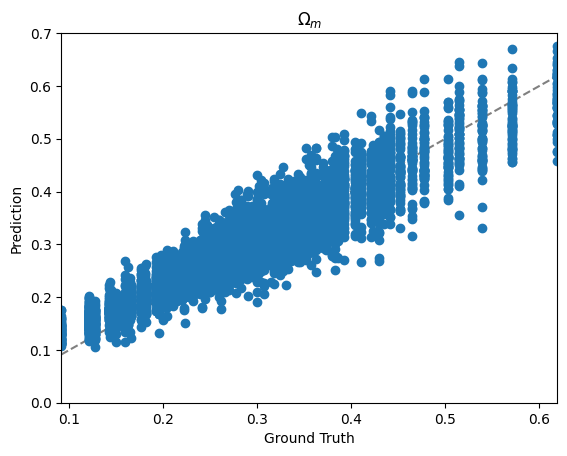

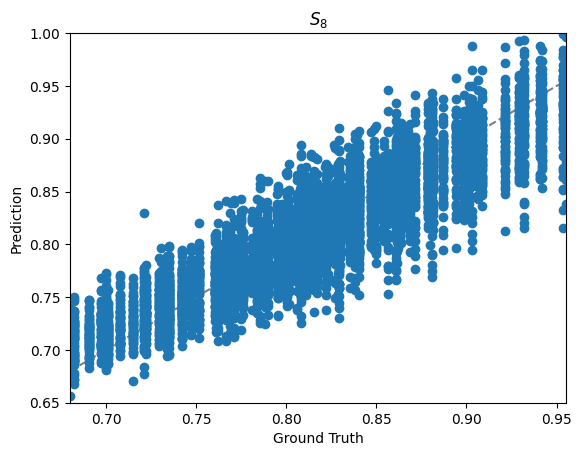

In [ ]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels
all_val_labels_inv = label_scaler.inverse_transform(all_val_labels)
plt.errorbar(all_val_labels_inv[:,0], mean_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels_inv[:,0]), sorted(all_val_labels_inv[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels_inv[:,0]), np.max(all_val_labels_inv[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(all_val_labels_inv[:,1], mean_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels_inv[:,1]), sorted(all_val_labels_inv[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels_inv[:,1]), np.max(all_val_labels_inv[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [ ]:
# Initialize Data class object
data_obj = Data(data_dir="./dataset", USE_PUBLIC_DATASET=True)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

Loading WIDE12H_bin2_2arcmin_kappa.npy: 100%|██████████| 11/11 [00:56<00:00,  5.18s/it]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy: 100%|██████████| 40/40 [00:07<00:00,  5.28it/s]


In [ ]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.


In [ ]:
# cosmology: (Ncosmo, 2)
# mean_val: (Nval, 2)
cosmology = data_obj.label[:,0,:2]   
dists = np.sum((all_val_labels_inv[:, None, :] - cosmology[None, :, :])**2, axis=2)  # (Nval, Ncosmo)
nearest_idx = np.argmin(dists, axis=1)  # for each validation sample, index of closest cosmology

# build index lists grouped by cosmology
index_lists = [[] for _ in range(cosmology.shape[0])]
for val_idx, cosmo_i in enumerate(nearest_idx):
    index_lists[cosmo_i].append(val_idx)

val_cosmology_idx = [np.array(lst, dtype=np.int32) for lst in index_lists]

In [ ]:
# # There are Ncosmo distinct cosmologies in the labels.
# # Here we create a list that groups the indices of the validation instances with the same cosmological parameters

# cosmology = data_obj.label[:,0,:2]   # shape = (Ncosmo, 2)

# row_to_i = {tuple(cosmology[i]): i for i in range(Ncosmo)}
# index_lists = [[] for _ in range(cosmology.shape[0])]

# # Loop over each row in 'y_val' with shape = (Nval, 2)
# for idx in range(len(all_val_labels_inv)):
#     row_tuple = tuple(all_val_labels_inv[idx])
#     i = row_to_i[row_tuple]
#     index_lists[i].append(idx)

# # val_cosmology_idx[i] = the indices idx of the validation examples with labels = cosmology[i]
# val_cosmology_idx = [np.array(lst) for lst in index_lists]  

In [ ]:
# The summary statistics of all realizations for all cosmologies in the validation set
d_vector = []  
n_d = 2   # Number of summary statistics for each map
for i in range(Ncosmo):
    d_i =  np.zeros((len(val_cosmology_idx[i]), n_d))  
    for j, idx in enumerate(val_cosmology_idx[i]):
        d_i[j] = mean_val[idx]

    d_vector.append(d_i)

In [ ]:
# mean summary statistics (average over all realizations)
mean_d_vector = []
for i in range(Ncosmo):
    mean_d_vector.append(np.mean(d_vector[i], 0))
mean_d_vector = np.array(mean_d_vector)   

# covariance matrix
delta = []
for i in range(Ncosmo):
    delta.append((d_vector[i] - mean_d_vector[i].reshape(1, n_d))) 

cov_d_vector = [(delta[i].T @ delta[i] / (len(delta[i])-n_d-2))[None] for i in range(Ncosmo)]     
cov_d_vector = np.concatenate(cov_d_vector, 0) 

In [ ]:
from scipy.interpolate import LinearNDInterpolator
mean_d_vector_interp = LinearNDInterpolator(cosmology, mean_d_vector, fill_value=np.nan)
cov_d_vector_interp = LinearNDInterpolator(cosmology, cov_d_vector, fill_value=np.nan)

In [ ]:
logprior_interp = LinearNDInterpolator(cosmology, np.zeros((Ncosmo, 1)), fill_value=-np.inf)

# Note that the training data are not uniformly sampled, which introduces a prior distribution. Here we ignore that prior for simplicity.
# Also note that this prior would introduce bias for cosmologies at the boundary of the prior
def log_prior(x):
    logprior = logprior_interp(x).flatten()  # shape = (Ntest, ) 
    return logprior

# Gaussian likelihood with interpolated mean and covariance matrix
def loglike(x, d):
    mean = mean_d_vector_interp(x) 
    cov = cov_d_vector_interp(x)   
    delta = d - mean               
    
    inv_cov = np.linalg.inv(cov)
    cov_det = np.linalg.slogdet(cov)[1]
    
    return -0.5 * cov_det - 0.5 * np.einsum("ni,nij,nj->n", delta, inv_cov, delta)

def logp_posterior(x, d):
    logp = log_prior(x)
    select = np.isfinite(logp)
    if np.sum(select) > 0:
        logp[select] = logp[select] + loglike(x[select], d[select])
    return logp

In [ ]:
Nval=all_val_labels_inv.shape[0]
print(Nval)

5656


In [ ]:
mean_val.shape

(5656, 2)

In [ ]:
# MCMC sampling to explore the posterior distribution

Nstep = 10000  # Number of MCMC steps (iterations)
sigma = 0.06   # Proposal standard deviation; should be tuned per method or parameter scale

# Randomly select initial points from the `cosmology` array for each test case
# Assumes `cosmology` has shape (Ncosmo, ndim) and `Ntest` is the number of independent chains/samples
current = cosmology[np.random.choice(Ncosmo, size=Nval)]

# Compute log-posterior at the initial points
curr_logprob = logp_posterior(current, mean_val)

# List to store sampled states (for all chains)
states = []

# Track total acceptance probabilities to compute acceptance rates
total_acc = np.zeros(len(current))

t = time.time()  # Track time for performance reporting

# MCMC loop
for i in range(Nstep):

    # Generate proposals by adding Gaussian noise to current state
    proposal = current + np.random.randn(*current.shape) * sigma    

    # Compute log-posterior at the proposed points
    proposal_logprob = logp_posterior(proposal, mean_val)

    # Compute log acceptance ratio (Metropolis-Hastings)
    acc_logprob = proposal_logprob - curr_logprob
    acc_logprob[acc_logprob > 0] = 0  # Cap at 0 to avoid exp overflow (acceptance prob ≤ 1)

    # Convert to acceptance probabilities
    acc_prob = np.exp(acc_logprob)

    # Decide whether to accept each proposal
    acc = np.random.uniform(size=len(current)) < acc_prob

    # Track acceptance probabilities (not binary outcomes)
    total_acc += acc_prob

    # Update states and log-probs where proposals are accepted
    current[acc] = proposal[acc]
    curr_logprob[acc] = proposal_logprob[acc]

    # Save a copy of the current state
    states.append(np.copy(current)[None])

    # Periodically print progress and acceptance rates
    if i % (0.1*Nstep) == 0.1*Nstep-1:
        print(
            'step:', len(states),
            'Time:', time.time() - t,
            'Min acceptance rate:', np.min(total_acc / (i + 1)),
            'Mean acceptance rate:', np.mean(total_acc / (i + 1))
        )
        t = time.time()  # Reset timer for next print interval

step: 1000 Time: 3.4934561252593994 Min acceptance rate: 0.039834482951808615 Mean acceptance rate: 0.2747029090365054
step: 2000 Time: 3.434379816055298 Min acceptance rate: 0.04311504174875431 Mean acceptance rate: 0.27408767977780896
step: 3000 Time: 3.4314470291137695 Min acceptance rate: 0.0372116699647306 Mean acceptance rate: 0.27384503534306726
step: 4000 Time: 3.3878259658813477 Min acceptance rate: 0.03309209515047611 Mean acceptance rate: 0.2737771781296505
step: 5000 Time: 3.40767502784729 Min acceptance rate: 0.03153216590383765 Mean acceptance rate: 0.2736540087061557
step: 6000 Time: 3.372051239013672 Min acceptance rate: 0.033508282451521765 Mean acceptance rate: 0.273554220485566
step: 7000 Time: 3.301564931869507 Min acceptance rate: 0.03510083506435767 Mean acceptance rate: 0.2735345904732616
step: 8000 Time: 3.323253870010376 Min acceptance rate: 0.03604759800140203 Mean acceptance rate: 0.27351173859483646
step: 9000 Time: 3.3306729793548584 Min acceptance rate: 0.

In [ ]:
y_pred_val=mean_val

In [ ]:
# remove burn-in
states = np.concatenate(states[int(0.2*Nstep):], 0)

# mean and std of samples
mean_val = np.mean(states, 0)
errorbar_val = np.std(states, 0)

In [ ]:
mean_val

array([[0.32275111, 0.78922171],
       [0.17459539, 0.92457064],
       [0.38050763, 0.77139778],
       ...,
       [0.15115937, 0.73978445],
       [0.29981843, 0.78082384],
       [0.42434592, 0.70056878]], shape=(5656, 2))

In [ ]:
y_val=all_val_labels_inv

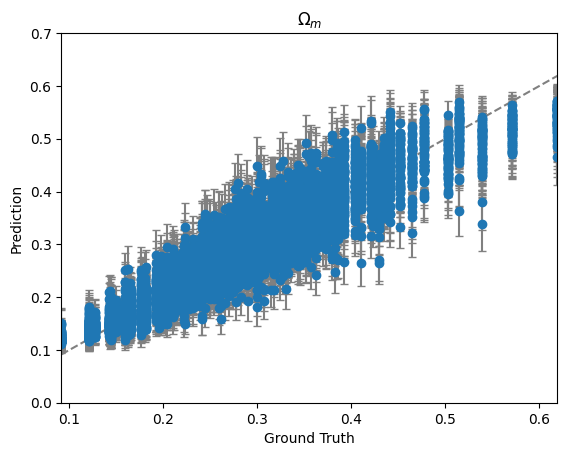

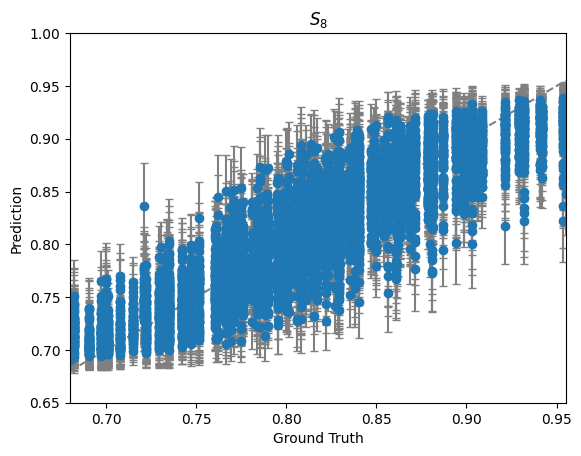

In [ ]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels

plt.errorbar(y_val[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,0]), sorted(y_val[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,0]), np.max(y_val[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(y_val[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,1]), sorted(y_val[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,1]), np.max(y_val[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [ ]:
validation_score = Score._score_phase1(
    true_cosmo=y_val,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))

averaged score: 9.64558297898673
averaged error bar: [0.03788582 0.02828034]


In [ ]:
test_Cl = np.zeros((data_obj.Ntest, Nbins))

for i in range(data_obj.Ntest):
    l, test_Cl[i] = power_spectrum(data_obj.kappa_test[i].astype(np.float64), data_obj.pixelsize_radian, l_edge)

test_logCl = np.log10(test_Cl)

In [ ]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    specs=test_Cl,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [ ]:
model.eval()
y_pred_list = []   
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for images, specs in test_loader:
        images = images.to(device, dtype=torch.float32)
        specs = specs.to(device, dtype=torch.float32)
        y_pred = model((images, specs))      
        y_pred = label_scaler.inverse_transform(y_pred.cpu().numpy())
        y_pred_list.append(y_pred) 

y_pred_test = np.concatenate(y_pred_list, axis=0)

Inference on the test set:   0%|          | 0/40 [00:17<?, ?it/s]


In [ ]:
y_pred_test

array([[0.3323444 , 0.8101712 ],
       [0.24685529, 0.9076852 ],
       [0.30787572, 0.88608307],
       ...,
       [0.2571584 , 0.85275304],
       [0.37525168, 0.7235798 ],
       [0.33895725, 0.97936785]], shape=(4000, 2), dtype=float32)

In [ ]:
# MCMC sampling to explore the posterior distribution

Nstep = 10000  # Number of MCMC steps (iterations)
sigma = 0.06   # Proposal standard deviation; should be tuned per method or parameter scale

# Randomly select initial points from the `cosmology` array for each test case
# Assumes `cosmology` has shape (Ncosmo, ndim) and `Ntest` is the number of independent chains/samples
current = cosmology[np.random.choice(Ncosmo, size=data_obj.Ntest)]

# Compute log-posterior at the initial points
curr_logprob = logp_posterior(current, y_pred_test)

# List to store sampled states (for all chains)
states = []

# Track total acceptance probabilities to compute acceptance rates
total_acc = np.zeros(len(current))

t = time.time()  # Track time for performance reporting

# MCMC loop
for i in range(Nstep):

    # Generate proposals by adding Gaussian noise to current state
    proposal = current + np.random.randn(*current.shape) * sigma    

    # Compute log-posterior at the proposed points
    proposal_logprob = logp_posterior(proposal, y_pred_test)

    # Compute log acceptance ratio (Metropolis-Hastings)
    acc_logprob = proposal_logprob - curr_logprob
    acc_logprob[acc_logprob > 0] = 0  # Cap at 0 to avoid exp overflow (acceptance prob ≤ 1)

    # Convert to acceptance probabilities
    acc_prob = np.exp(acc_logprob)

    # Decide whether to accept each proposal
    acc = np.random.uniform(size=len(current)) < acc_prob

    # Track acceptance probabilities (not binary outcomes)
    total_acc += acc_prob

    # Update states and log-probs where proposals are accepted
    current[acc] = proposal[acc]
    curr_logprob[acc] = proposal_logprob[acc]

    # Save a copy of the current state
    states.append(np.copy(current)[None])

    # Periodically print progress and acceptance rates
    if i % (0.1*Nstep) == 0.1*Nstep-1:
        print(
            'step:', len(states),
            'Time:', time.time() - t,
            'Min acceptance rate:', np.min(total_acc / (i + 1)),
            'Mean acceptance rate:', np.mean(total_acc / (i + 1))
        )
        t = time.time()  # Reset timer for next print interval

step: 1000 Time: 2.481208086013794 Min acceptance rate: 0.029646574807667223 Mean acceptance rate: 0.2725225882700893
step: 2000 Time: 2.425226926803589 Min acceptance rate: 0.023826265777407967 Mean acceptance rate: 0.2718404443878606
step: 3000 Time: 2.5918941497802734 Min acceptance rate: 0.02584722421250155 Mean acceptance rate: 0.27160460125097924
step: 4000 Time: 2.648897886276245 Min acceptance rate: 0.024780888095046014 Mean acceptance rate: 0.2714382882464456
step: 5000 Time: 2.5421688556671143 Min acceptance rate: 0.026147510184602304 Mean acceptance rate: 0.27138676268474754
step: 6000 Time: 2.4403109550476074 Min acceptance rate: 0.026439766556769877 Mean acceptance rate: 0.27138904770439487
step: 7000 Time: 2.4066851139068604 Min acceptance rate: 0.027436334291233655 Mean acceptance rate: 0.2713632260351771
step: 8000 Time: 2.4437761306762695 Min acceptance rate: 0.027221659304224523 Mean acceptance rate: 0.2713614571390279
step: 9000 Time: 2.509350061416626 Min acceptance

In [ ]:
# remove burn-in
states = np.concatenate(states[int(0.2*Nstep):], 0)

# mean and std of samples
mean = np.mean(states, 0)
errorbar = np.std(states, 0)

In [ ]:
states

array([[[0.29330328, 0.84884842],
        [0.22654499, 0.90316923],
        [0.31362913, 0.90143714],
        ...,
        [0.28916618, 0.88546686],
        [0.39780187, 0.70200318],
        [0.36151322, 0.92701847]],

       [[0.30861425, 0.85700884],
        [0.22654499, 0.90316923],
        [0.31362913, 0.90143714],
        ...,
        [0.28916618, 0.88546686],
        [0.39780187, 0.70200318],
        [0.36151322, 0.92701847]],

       [[0.29233961, 0.85983321],
        [0.22654499, 0.90316923],
        [0.31362913, 0.90143714],
        ...,
        [0.28916618, 0.88546686],
        [0.39780187, 0.70200318],
        [0.36151322, 0.92701847]],

       ...,

       [[0.31414224, 0.79141077],
        [0.28698859, 0.91247935],
        [0.29646039, 0.89174142],
        ...,
        [0.23957564, 0.88006059],
        [0.3345693 , 0.74619853],
        [0.39237827, 0.90906764]],

       [[0.32661303, 0.83974653],
        [0.28698859, 0.91247935],
        [0.29646039, 0.89174142],
        .

In [ ]:
mean

array([[0.33865899, 0.81613947],
       [0.24217184, 0.90966017],
       [0.31336784, 0.89565414],
       ...,
       [0.25268216, 0.86194309],
       [0.38085032, 0.71487383],
       [0.32941156, 0.92874138]], shape=(4000, 2))

In [ ]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_25-09-21-02-56.zip
